# Exploratory data analysis on the dsn mart data 

This Basic EDA Notebook was modelled after [chris deolites notebook on Basic EDA](https://www.kaggle.com/code/cdeotte/basic-eda-customer-churn/)

## Phase: 1 Importing needed libraries and the data 

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [59]:
# major directory file_path.
DIR = "data/"

# specific filepaths
train_path = f"{DIR}train.csv"
test_path = f"{DIR}test.csv"
sample_path = f"{DIR}sample_submission.csv"

# importing the files using pandas read_csv
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample = pd.read_csv(sample_path)

In [60]:

def normalize_capitalization(df, old_column):
    """
    Normalizes case/whitespace duplicates in a categorical column
    (e.g. 'seafood', 'SEAFOOD', 'SeaFood' -> 'seafood') and writes
    the result into a new column.
    
    params: 
    df - your dataframe
    old_column - column with inconsistent capitalization
    new_column - column with corrected capitalization
    """
    df = df.copy()
    df[old_column] = (df[old_column]
        .astype(str)
        .str.strip()
        .str.lower())
    
    return df

In [61]:
train = normalize_capitalization(train, "product_category")

In [62]:
test = normalize_capitalization(test, "product_category")

## Phase: 2  Basic EDA 

In [41]:
# check the data
# Hide this 
def basic_data(df: DataFrame, name: str, for_y = 0):
    """
    function prints the shape of the data
    """
    if for_y == 0:
        shape = df.shape
        print(f"The {name} dataframe has {shape[0]} Rows and {shape[1]} Columns")
        print('*'* 30)
    else:
        shape = df.shape
        print(f"The {name} dataframe has {shape[0]} Rows")
        print('*'* 30)

In [42]:
basic_data(train, "train")
basic_data(test, "test")
basic_data(sample, "sample_submission")

The train dataframe has 6818 Rows and 13 Columns
******************************
The test dataframe has 1705 Rows and 12 Columns
******************************
The sample_submission dataframe has 1705 Rows and 2 Columns
******************************


### Description of the columns in the train data 
|column|Description|
|------|-----------|
|id| Unique row identifier|
| product_code| Unique code for the product|
|product_weight_kg |	Weight of the product in kilograms (some values are missing)|
|fat_content |	Whether the product is labelled "Low Fat" or "Regular"|
|shelf_visibility |	The proportion of total display area in the store allocated to this product|
|product_category |	The product's category (note: capitalization is inconsistent — that's real-world data, not a bug)|
|product_price |	The product's listed price|
|store_code |	Unique code for the store|
|store_size |	The store's size category: Small, Medium, or Large (some values are missing)|
|store_location_tier |	The tier of the store's location — Tier_1 (major urban centers), Tier_2 (state capitals), Tier_3 (smaller towns)|
|store_format |	The store's format: Corner Shop, Standard Supermarket, Superstore, or Flagship Hypermarket|
|total_sales |	Target. Total sales value for this product at this store (train only)|

In [43]:
# print the percentage of missing values in the df per column 
""" we are dividing the total missing values in a column/by the total no of rows 
    then multiplying it by 100 giving the percent missing values if you want the
    total missing values modify the function """
def check_nan_state(df, name):
    total_rows = len(df)
    if total_rows == 0:
        print("Dataframe is empty !!!")
    else:
        nan_percent = (df.isna().sum()/ total_rows * 100).round(2)
        nan_percent_display = pd.DataFrame({"Column" : nan_percent.index,
                                            "Percent missing" : nan_percent.values}).sort_values("Percent missing"
                                                                                                 , ascending = False)
        print(f"Percent values of NAN values in {name} dataframe ")
        display(nan_percent_display)

In [54]:
check_nan_state(train, "train")

Percent values of NAN values in train dataframe 


,Column,Percent missing
13,product_weight,100.00
9,store_size,28.15
2,product_weight_kg,17.97
3,fat_content,0.00
1,product_code,0.00
0,id,0.00
5,product_category,0.00
4,shelf_visibility,0.00
7,store_code,0.00
6,product_price,0.00


In [45]:
# check out the statistical distribution of the numerical columns in the df
train.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


notice that spike from 75% percentile total sales of 3k to 100% percentile total sales of 12k some thing is there

- the 12k total sales is  under `HOUSEHOLD`, `fruitsandvegitables` in product_category
- we also have 10k total sales under `Dairy` in the product_category i would do a more indepth search on this spike it might be outliers

now checking from store formats this follows normal conventions 
|store_format|   total_sales |
|------------|------------------|
|Corner Shop  |            1830.37|
|Flagship Hypermarket |   12996.82|
|Standard Supermarket |   10130.90|
|Superstore          |     7016.22|


#### Flagship Hypermarket EDA Find all NAN values in the product_weight_kg colum
Found this detail by mistake see that the categorical value Flagship Hypermarket doesnt have any product_weight_kg 
so my solution would be instead of taking the global mean for filling the nan values 

we use the product_category column to check for each products mean/average weight then use that to fill the nan values 
works well no well we explore also if it works well 

In [75]:
train["store_format"].value_counts()

store_format
Standard Supermarket    4462
Corner Shop              866
Flagship Hypermarket     748
Superstore               742
Name: count, dtype: int64

In [73]:
pd.crosstab(train['store_size'], train['store_format'])

store_format,Corner Shop,Flagship Hypermarket,Standard Supermarket,Superstore
store_size,,,,
Large,0,0,748,0
Medium,0,748,728,742
Small,427,0,1506,0


- so from the detail above all corner shops should be of `small` store_size most of then are nan 400+
but for standard supermarket with spread out shops we cant be sure that most frequent is the correct way to fill the nan values

In [80]:
pd.crosstab(train['store_location_tier'], train['store_format'])

store_format,Corner Shop,Flagship Hypermarket,Standard Supermarket,Superstore
store_location_tier,,,,
Tier_1,427,0,1482,0
Tier_2,0,0,2232,0
Tier_3,439,748,748,742


In [81]:
pd.crosstab(train['store_location_tier'], train['store_size'])

store_size,Large,Medium,Small
store_location_tier,,,
Tier_1,0,728,1181
Tier_2,0,0,752
Tier_3,748,1490,0


thinking maybe corner_shop has no tier_3 shops  all of it are NAN values 
like if the store format is `corner shop` and the store_location_tier is `Tier_3` the value of the store_size is garanteed to be a NAN value

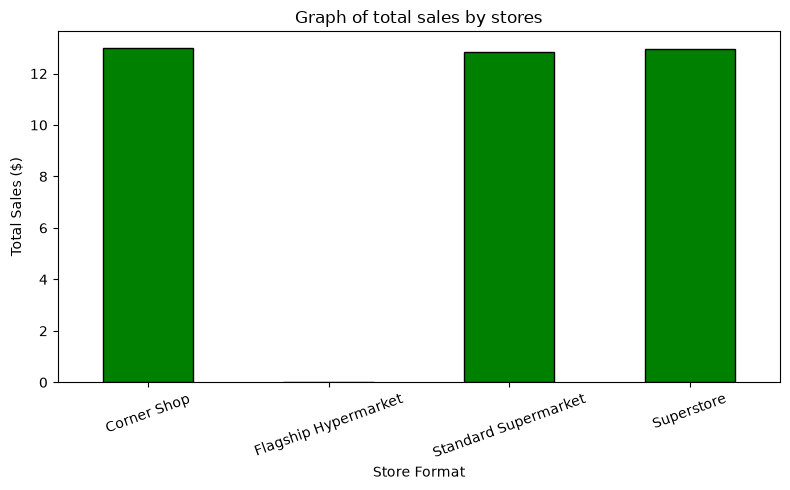

In [32]:
store_format_by_total_sales = train.groupby("store_format")["product_weight_kg"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
store_format_by_total_sales.plot(kind='bar', ax=ax, color='green', edgecolor='black')
ax.set_title('Graph of total sales by stores')
ax.set_xlabel('Store Format')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [35]:
# See how many NaNs exist per group, and group sizes
train.groupby("store_format")["product_weight_kg"].agg(['count', 'size'])

,count,size
store_format,,
Corner Shop,439,866
Flagship Hypermarket,0,748
Standard Supermarket,4420,4462
Superstore,734,742


now to observe on the store_size column and check if theres any correlation like the above there also 

In [67]:
train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,frozen foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,health and hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,12.900,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


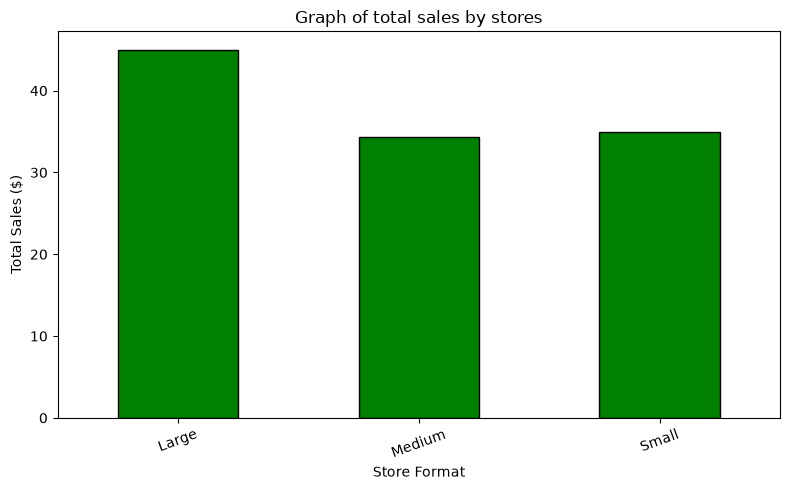

In [71]:
store_format_by_total_sales = train.groupby("store_size")["store_age_years"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
store_format_by_total_sales.plot(kind='bar', ax=ax, color='green', edgecolor='black')
ax.set_title('Graph of total sales by stores')
ax.set_xlabel('Store Format')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#### Other EDA 

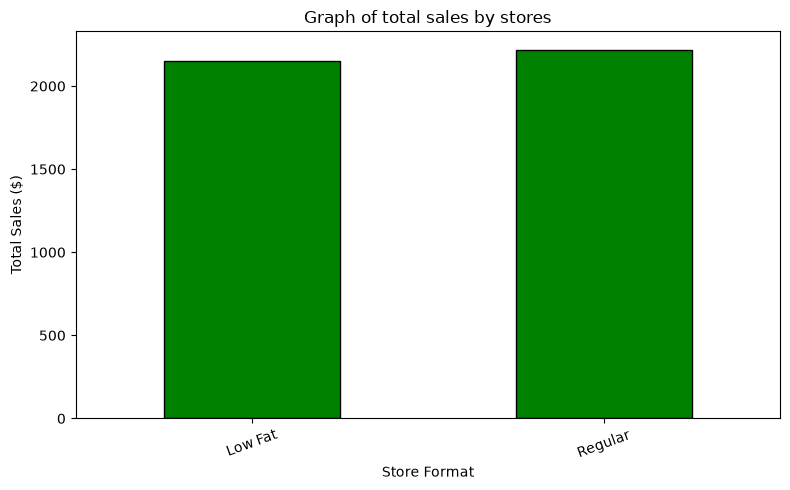

In [18]:
store_format_by_total_sales = train.groupby("fat_content")["total_sales"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
store_format_by_total_sales.plot(kind='bar', ax=ax, color='green', edgecolor='black')
ax.set_title('Graph of total sales by stores')
ax.set_xlabel('Store Format')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [3]:
def plot_features_dual_axis(
    df: pd.DataFrame,
    cols: list[str],
    target_col: float,
    n_bins: int = 10,
    n_wide: int = 3,
    figsize_per_plot: tuple[float, float] = (5, 4),
    int_as_cat_unique_max: int | None = 20,
    cat_order: dict[str, list] | None = None,   # <-- NEW
):
    BAR_COLOR = "tab:blue"
    LINE_COLOR = "tab:orange"

    def is_categorical(s: pd.Series) -> bool:
        return s.dtype == "object" or pd.api.types.is_string_dtype(s)

    n_cols = len(cols)
    n_rows = int(np.ceil(n_cols / n_wide))

    fig, axes = plt.subplots(
        n_rows,
        n_wide,
        figsize=(figsize_per_plot[0] * n_wide, figsize_per_plot[1] * n_rows),
    )

    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax1 = axes[i]
        col_safe = col.replace("_", r"\_")

        n_nan = df[col].isna().sum()
        n_unique = df[col].nunique(dropna=True)

        tmp = df[[col, target_col]].dropna()
        if tmp.empty:
            ax1.set_title(
                rf"$\bf{{{col_safe}}}$"
                f"\n(empty after dropna; {n_unique} unique, {n_nan} nan)"
            )
            continue

        x = tmp[col]
        y = tmp[target_col]

        # ---------- TRUE CATEGORICAL ----------
        if is_categorical(x):
            type_str = "categorical"

            # base counts / means
            counts = x.value_counts()
            mean_y = tmp.groupby(col)[target_col].mean()

            # ---- APPLY USER-DEFINED CATEGORY ORDER (if provided) ----
            if cat_order is not None and col in cat_order:
                desired = list(cat_order[col])

                # keep only categories present in data
                ordered = [c for c in desired if c in counts.index]

                # append any remaining categories not specified by user
                remaining = [c for c in counts.index if c not in ordered]
                final_order = ordered + remaining
            else:
                final_order = sorted(counts.index)

            counts = counts.loc[final_order]
            mean_y = mean_y.loc[final_order]

            xpos = np.arange(len(final_order))

            ax1.bar(xpos, counts.values, alpha=0.6, color=BAR_COLOR)
            ax1.set_xlabel(col)
            ax1.set_ylabel("Count", color=BAR_COLOR)
            ax1.tick_params(axis="y", colors=BAR_COLOR)

            ax1.set_xticks(xpos)
            ax1.set_xticklabels(final_order, rotation=45, ha="right")

            ax2 = ax1.twinx()
            ax2.plot(xpos, mean_y.values, marker="o", color=LINE_COLOR)
            ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
            ax2.tick_params(axis="y", colors=LINE_COLOR)

            ax1.set_title(
                rf"$\bf{{{col_safe}}}$: Count vs Mean {target_col}"
                f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
            )

        # ---------- NUMERIC ----------
        else:
            type_str = "numeric"

            xvals = x.values
            yvals = y.values

            mask = np.isfinite(xvals) & np.isfinite(yvals)
            xvals = xvals[mask]
            yvals = yvals[mask]

            if len(xvals) == 0:
                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )
                continue

            unique_vals = np.sort(np.unique(xvals))
            n_unique_eff = len(unique_vals)

            # --- Case 1: int-as-categorical ---
            if int_as_cat_unique_max is not None and n_unique_eff <= int_as_cat_unique_max:
                counts = np.array([(xvals == v).sum() for v in unique_vals])
                mean_y = np.array([yvals[xvals == v].mean() for v in unique_vals])

                xpos = np.arange(n_unique_eff)

                ax1.bar(xpos, counts, alpha=0.6, color=BAR_COLOR)
                ax1.set_xlabel(col)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                rotate = 45 if n_unique_eff > n_bins else 0
                step = max(int(np.ceil(n_unique_eff / n_bins)), 1)
                tick_idx = np.arange(0, n_unique_eff, step)

                if pd.api.types.is_integer_dtype(x):
                    tick_labels = unique_vals[tick_idx].astype(int)
                else:
                    tick_labels = unique_vals[tick_idx]

                ax1.set_xticks(tick_idx)
                ax1.set_xticklabels(
                    tick_labels,
                    rotation=rotate,
                    ha="right" if rotate else "center",
                )

                ax2 = ax1.twinx()
                ax2.plot(xpos, mean_y, marker="o", color=LINE_COLOR)
                ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$: Per-Value Count vs Mean {target_col}"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )

            # --- Case 2: low-cardinality numeric bins ---
            elif n_unique_eff < n_bins:
                counts = np.array([(xvals == v).sum() for v in unique_vals])
                mean_y = np.array([yvals[xvals == v].mean() for v in unique_vals])

                width = 0.8 * (np.min(np.diff(unique_vals)) if n_unique_eff > 1 else 1.0)

                ax1.bar(unique_vals, counts, width=width, alpha=0.6, color=BAR_COLOR)
                ax1.set_xlabel(col)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                ax2 = ax1.twinx()
                ax2.plot(unique_vals, mean_y, marker="o", color=LINE_COLOR)
                ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$: Per-Value Count vs Mean {target_col}"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )

            # --- Case 3: regular histogram ---
            else:
                bins = np.linspace(xvals.min(), xvals.max(), n_bins + 1)
                bin_centers = 0.5 * (bins[:-1] + bins[1:])

                counts, _ = np.histogram(xvals, bins=bins)
                bin_idx = np.digitize(xvals, bins) - 1

                mean_y = np.array([
                    yvals[bin_idx == j].mean() if np.any(bin_idx == j) else np.nan
                    for j in range(n_bins)
                ])

                ax1.bar(
                    bin_centers,
                    counts,
                    width=(bins[1] - bins[0]),
                    alpha=0.6,
                    color=BAR_COLOR,
                )
                ax1.set_xlabel(col)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                ax2 = ax1.twinx()
                ax2.plot(bin_centers, mean_y, marker="o", color=LINE_COLOR)
                ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$: Histogram vs Mean {target_col}"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [4]:
FEATURES = list( train.columns[1:-1] )
print(f"There are {len(FEATURES)} features:")
print(FEATURES)

There are 11 features:
['product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format']


In [5]:
train.columns

Index(['id', 'product_code', 'product_weight_kg', 'fat_content',
       'shelf_visibility', 'product_category', 'product_price', 'store_code',
       'store_age_years', 'store_size', 'store_location_tier', 'store_format',
       'total_sales'],
      dtype='str')

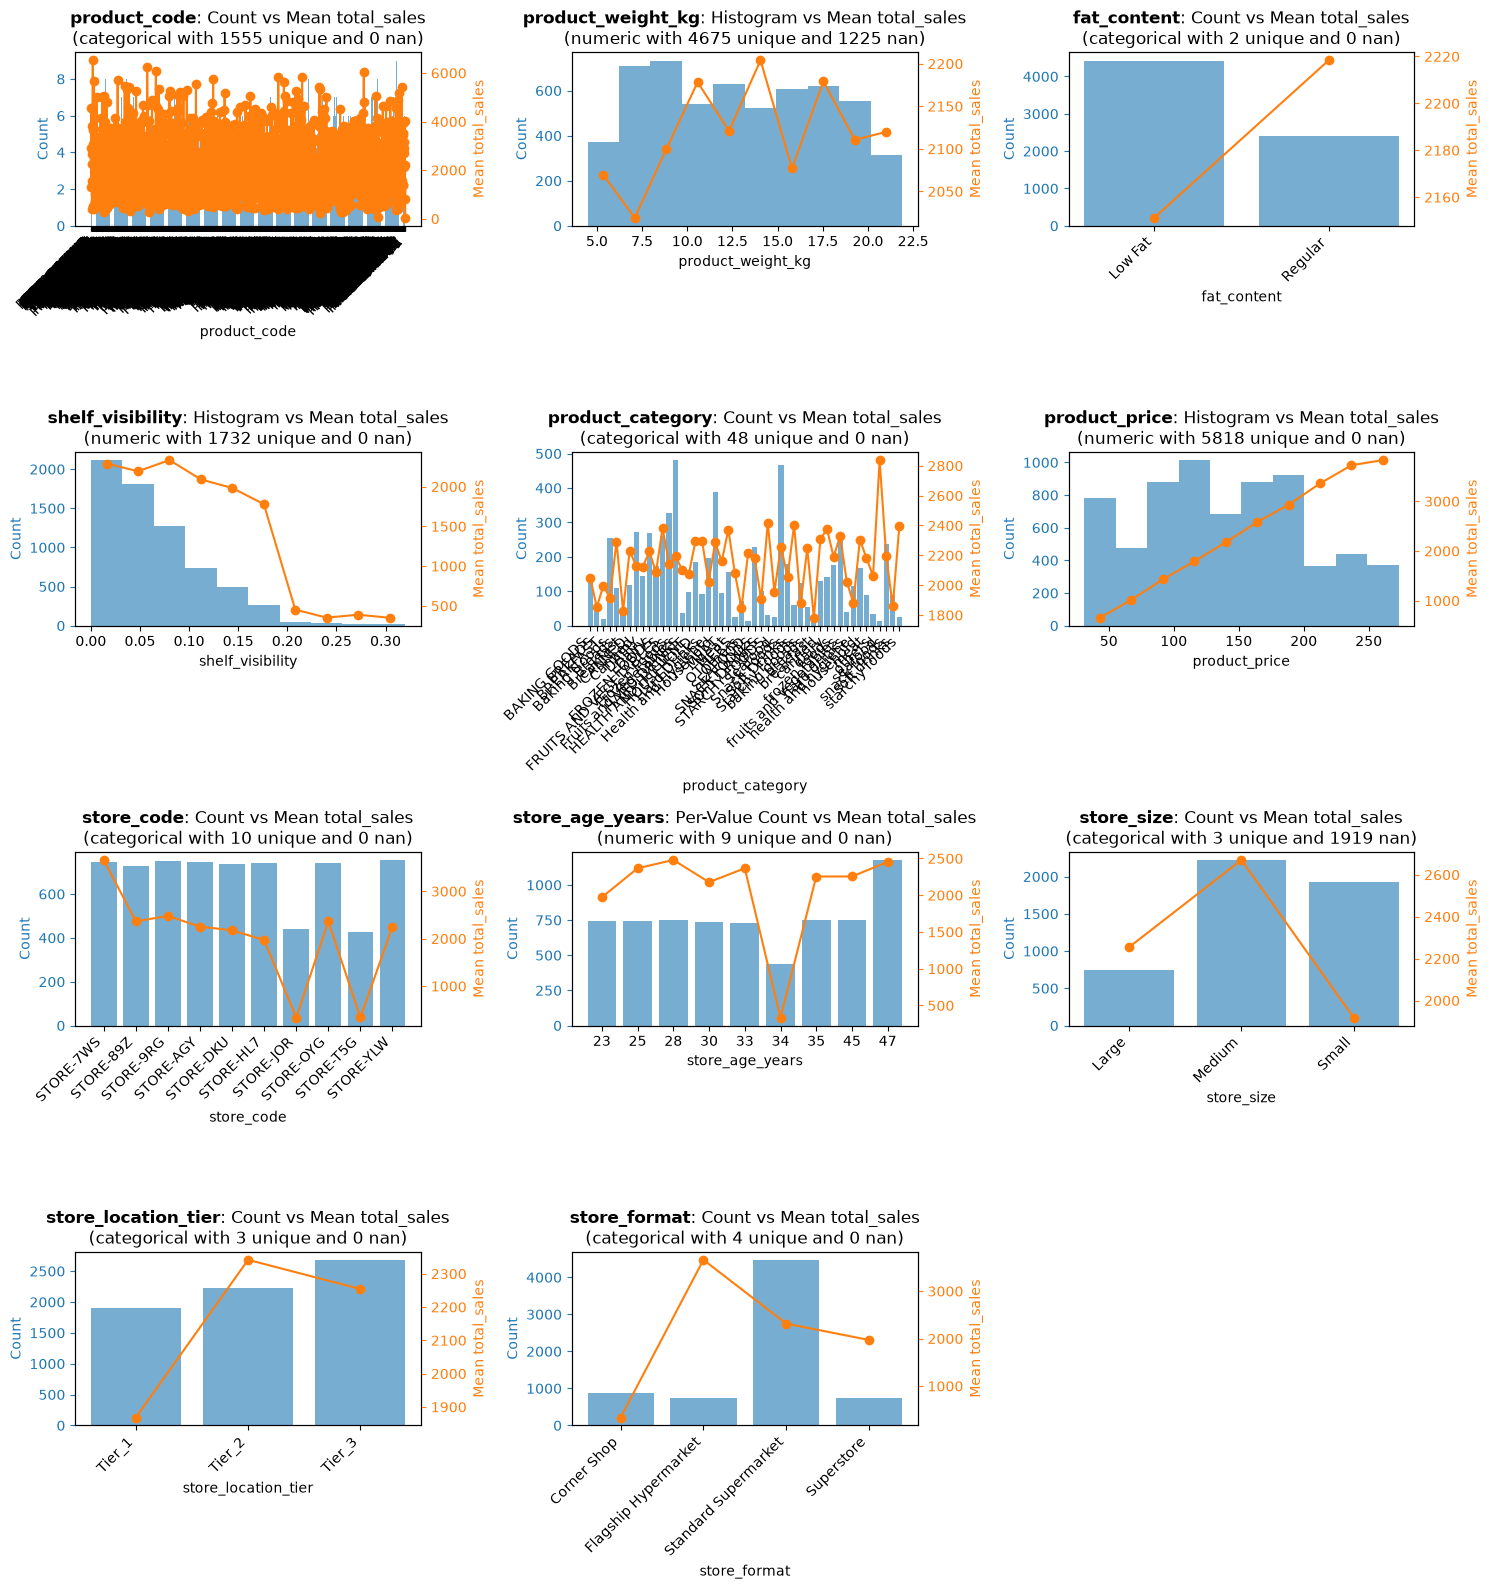

In [6]:
plot_features_dual_axis(
    train,
    cols=FEATURES,
    target_col="total_sales",
    n_bins=10,
    n_wide=3,
    int_as_cat_unique_max=20,
    cat_order = {},
)